In [11]:
#실습용 라이브러리 설치

!pip install numpy==1.26.4 --upgrade -qqq

!pip install pinecone-client==3.2.2 sentence-transformers==2.7.0 datasets==2.18.0 faiss-cpu==1.8.0 transformers==4.40.1 openai llama-index==0.10.34 llama-index-vector-stores-pinecone==0.1.6 llama-index-embeddings-huggingface==0.1.4 -qqq

In [12]:
# 예제 12.14 실습 데이터셋 다운로드

from datasets import load_dataset

dataset = load_dataset("poloclub/diffusiondb", "2m_first_1k", split='train', trust_remote_code=True)

example_index = 867
original_image = dataset[example_index]['image']
original_prompt = dataset[example_index]['prompt']
print(original_prompt)

# cute fluffy baby cat rabbit lion hybrid mixed creature character concept,
# with long flowing mane blowing in the wind, long peacock feather tail,
# wearing headdress of tribal peacock feathers and flowers, detailed painting,
# renaissance, 4 k

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


cute fluffy baby cat rabbit lion hybrid mixed creature character concept, with long flowing mane blowing in the wind, long peacock feather tail, wearing headdress of tribal peacock feathers and flowers, detailed painting, renaissance, 4 k 


In [ ]:
# 예제 12.15 GPT-4o 요청에 사용할 함수 (수정본)

import requests
import base64
from io import BytesIO
from google.colab import userdata

# Colab Secret에 저장된 API Key 불러오기
# Secret 이름: OPENAI_API_KEY
OPENAI_API_KEY = userdata.get("OPENAI_API_KEY")  # 본인의 API Key 입력

if not OPENAI_API_KEY:
    raise ValueError("Colab Secret에 OPENAI_API_KEY를 먼저 등록하세요.")

def make_base64(image):
    buffered = BytesIO()
    image.save(buffered, format="JPEG")
    img_str = base64.b64encode(buffered.getvalue()).decode("utf-8")
    return img_str

def generate_description_from_image_gpt4(prompt, image64):
    headers = {
        "Content-Type": "application/json",
        "Authorization": f"Bearer {OPENAI_API_KEY}"
    }

    payload = {
        "model": "gpt-4o",
        "messages": [
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": prompt
                    },
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/jpeg;base64,{image64}"
                        }
                    }
                ]
            }
        ],
        "max_tokens": 300
    }

    response_oai = requests.post(
        "https://api.openai.com/v1/chat/completions",
        headers=headers,
        json=payload
    )

    if response_oai.status_code != 200:
        raise RuntimeError(
            f"OpenAI API 요청 실패: {response_oai.status_code}\n{response_oai.text}"
        )

    result = response_oai.json()["choices"][0]["message"]["content"]
    return result

In [14]:
# 예제 12.16 이미지 설명 생성

image_base64 = make_base64(original_image)
described_result = generate_description_from_image_gpt4("Describe provided image in both English and Korean", image_base64)
described_result
# The image depicts a digitally created, fantastical creature that combines features of different animals. It has the body and face of a lion, with a rich, golden mane that transitions into an array of vibrant, peacock-like feathers. The feathers themselves are full of brilliant colors, primarily blues and greens, with "eyes" that mimic the look of a peacock's plumage. The creature is sitting down and facing forward with a calm and majestic expression.
# The creature is set against a picturesque backdrop that resembles a lush, blooming meadow or garden, with rolling green hills in the distance and a blue sky above. The colors are rich and the composition is balanced, emphasizing the surreal and regal aspect of the creature. It's an imaginative piece that blends the natural elements of these animals in a mystical way.
# 이 이미지는 다양한 동물의 특징을 결합한 디지털로 창조된 환상적인 생물을 묘사합니다. 이 동물은 사자의 몸과 얼굴을 하고 있으며, 풍성한 황금빛 갈기가 공작새와 같은 생생한 깃털로 변합니다. 깃털은 주로 파란색과 녹색의 화려한 색상으로 가득하며, 공작의 깃털을 닮은 '눈'이 있습니다. 이 생물은 차분하고 장엄한 표정으로 앉아서 정면을 바라보고 있습니다.
# 이 생물은 무성하고 꽃이 만발한 초원이나 정원을 연상시키는 그림 같은 배경을 배경으로 멀리 푸른 언덕이 펼쳐져 있고 위로는 푸른 하늘이 펼쳐져 있습니다. 색상이 풍부하고 구도가 균형 잡혀 있어 초현실적이고 당당한 생물의 모습을 강조합니다. 동물의 자연적 요소를 신비로운 방식으로 혼합한 상상력이 돋보이는 작품입니다.

'The image shows a majestic lion with a unique appearance. The lion has a mane that resembles peacock feathers, with vibrant colors like blues, greens, and purples. It is set against a natural background with flowers and greenery, creating a mystical and enchanting atmosphere.\n\n이 이미지는 독특한 외모를 가진 웅장한 사자를 보여줍니다. 사자의 갈기는 공작새의 깃털을 닮았으며, 파란색, 초록색, 보라색 같은 생생한 색상이 특징입니다. 꽃과 초록색 식물들이 있는 자연 배경 속에서 신비롭고 매혹적인 분위기를 자아내고 있습니다.'

In [ ]:
# 예제 12.17 클라이언트 준비

import os
from openai import OpenAI
from pinecone import Pinecone, ServerlessSpec
import httpx
from google.colab import userdata

# Colab Secret에서 API Key 불러오기
PINECONE_API_KEY = userdata.get("PINECONE_API_KEY")   # 본인의 API Key 입력(Colab Secret)
OPENAI_API_KEY = userdata.get("OPENAI_API_KEY")       # 본인의 API Key 입력(Colab Secret)

pc = Pinecone(api_key=PINECONE_API_KEY)
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

custom_httpx_client = httpx.Client()
client = OpenAI(
    api_key=OPENAI_API_KEY,
    http_client=custom_httpx_client
)

In [16]:
#예제 12.18 인덱스 생성

print(pc.list_indexes())

index_name = "llm-multimodal"
try:
  pc.create_index(
    name=index_name,
    dimension=512,
    metric="cosine",
    spec=ServerlessSpec(
      "aws", "us-east-1"
    )
  )
  print(pc.list_indexes())
except:
  print("Index already exists")
index = pc.Index(index_name)

{'indexes': [{'dimension': 768,
              'host': 'llm-book-7se30sy.svc.aped-4627-b74a.pinecone.io',
              'metric': 'cosine',
              'name': 'llm-book',
              'spec': {'serverless': {'cloud': 'aws', 'region': 'us-east-1'}},
              'status': {'ready': True, 'state': 'Ready'}},
             {'dimension': 768,
              'host': 'quickstart-7se30sy.svc.aped-4627-b74a.pinecone.io',
              'metric': 'euclidean',
              'name': 'quickstart',
              'spec': {'serverless': {'cloud': 'aws', 'region': 'us-east-1'}},
              'status': {'ready': True, 'state': 'Ready'}},
             {'dimension': 1024,
              'host': 'vector-data-7se30sy.svc.aped-4627-b74a.pinecone.io',
              'metric': 'cosine',
              'name': 'vector-data',
              'spec': {'serverless': {'cloud': 'aws', 'region': 'us-east-1'}},
              'status': {'ready': True, 'state': 'Ready'}},
             {'dimension': 512,
              'hos

In [17]:
# 예제 12.19 프롬프트 텍스트를 텍스트 임베딩 모델을 활용해 임베딩 벡터로 변환

import torch
from tqdm.auto import trange
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, CLIPTextModelWithProjection

device = "cuda" if torch.cuda.is_available() else "cpu"

text_model = CLIPTextModelWithProjection.from_pretrained("openai/clip-vit-base-patch32")
tokenizer = AutoTokenizer.from_pretrained("openai/clip-vit-base-patch32")

tokens = tokenizer(dataset['prompt'], padding=True, return_tensors="pt", truncation=True)
batch_size = 16
text_embs = []
for start_idx in trange(0, len(dataset), batch_size):
    with torch.no_grad():
        outputs = text_model(input_ids = tokens['input_ids'][start_idx:start_idx+batch_size],
                        attention_mask = tokens['attention_mask'][start_idx:start_idx+batch_size])
        text_emb_tmp = outputs.text_embeds
    text_embs.append(text_emb_tmp)
text_embs = torch.cat(text_embs, dim=0)
text_embs.shape # (1000, 512)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


  0%|          | 0/63 [00:00<?, ?it/s]

torch.Size([1000, 512])

In [18]:
#예제 12.20 텍스트 임베딩 벡터를 파인콘 인덱스에 저장

input_data = []
for id_int, emb, prompt in zip(range(0, len(dataset)), text_embs.tolist(), dataset['prompt']):
  input_data.append(
      {
          "id": str(id_int),
          "values": emb,
          "metadata": {
              "prompt": prompt
          }
      }
  )

index.upsert(
  vectors=input_data
)

{'upserted_count': 1000}

In [19]:
# 예제 12.21 이미지 임베딩을 사용한 유사 프롬프트 검색

from transformers import AutoProcessor, CLIPVisionModelWithProjection

vision_model = CLIPVisionModelWithProjection.from_pretrained("openai/clip-vit-base-patch32")
processor = AutoProcessor.from_pretrained("openai/clip-vit-base-patch32")

inputs = processor(images=original_image, return_tensors="pt")

outputs = vision_model(**inputs)
image_embeds = outputs.image_embeds

search_results = index.query(
  vector=image_embeds[0].tolist(),
  top_k=3,
  include_values=False,
  include_metadata=True
)
searched_idx = int(search_results['matches'][0]['id'])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [20]:
# 예제 12.22 이미지 임베딩을 사용해 검색한 유사 프롬프트 확인

search_results

# {'matches': [{'id': '918',
#               'metadata': {'prompt': 'cute fluffy bunny cat lion hybrid mixed '
#                                      'creature character concept, with long '
#                                      'flowing mane blowing in the wind, long '
#                                      'peacock feather tail, wearing headdress '
#                                      'of tribal peacock feathers and flowers, '
#                                      'detailed painting, renaissance, 4 k '},
#               'score': 0.372838408,
#               'values': []},
#              {'id': '867',
#               'metadata': {'prompt': 'cute fluffy baby cat rabbit lion hybrid '
#                                      'mixed creature character concept, with '
#                                      'long flowing mane blowing in the wind, '
#                                      'long peacock feather tail, wearing '
#                                      'headdress of tribal peacock feathers and '
#                                      'flowers, detailed painting, renaissance, '
#                                      '4 k '},
#               'score': 0.371655703,
#               'values': []},
# ...

{'matches': [{'id': '918',
              'metadata': {'prompt': 'cute fluffy bunny cat lion hybrid mixed '
                                     'creature character concept, with long '
                                     'flowing mane blowing in the wind, long '
                                     'peacock feather tail, wearing headdress '
                                     'of tribal peacock feathers and flowers, '
                                     'detailed painting, renaissance, 4 k '},
              'score': 0.37662074,
              'values': []},
             {'id': '867',
              'metadata': {'prompt': 'cute fluffy baby cat rabbit lion hybrid '
                                     'mixed creature character concept, with '
                                     'long flowing mane blowing in the wind, '
                                     'long peacock feather tail, wearing '
                                     'headdress of tribal peacock feathers and '
             

In [28]:
# 예제 12.23 프롬프트로 이미지를 생성하고 저장하는 함수 정의 (최종 수정본)

from openai import OpenAI
from PIL import Image
import base64
from io import BytesIO

client = OpenAI()  # 이미 초기화되어 있으면 생략 가능

def generate_image(prompt, filename=None):
    response_oai = client.images.generate(
        model="gpt-image-1",
        prompt=str(prompt),
        size="1024x1024",
        quality="medium",   # standard → medium 으로 변경
        n=1
    )

    image_base64 = response_oai.data[0].b64_json
    image_bytes = base64.b64decode(image_base64)
    image = Image.open(BytesIO(image_bytes))

    if filename:
        image.save(filename)

    return image

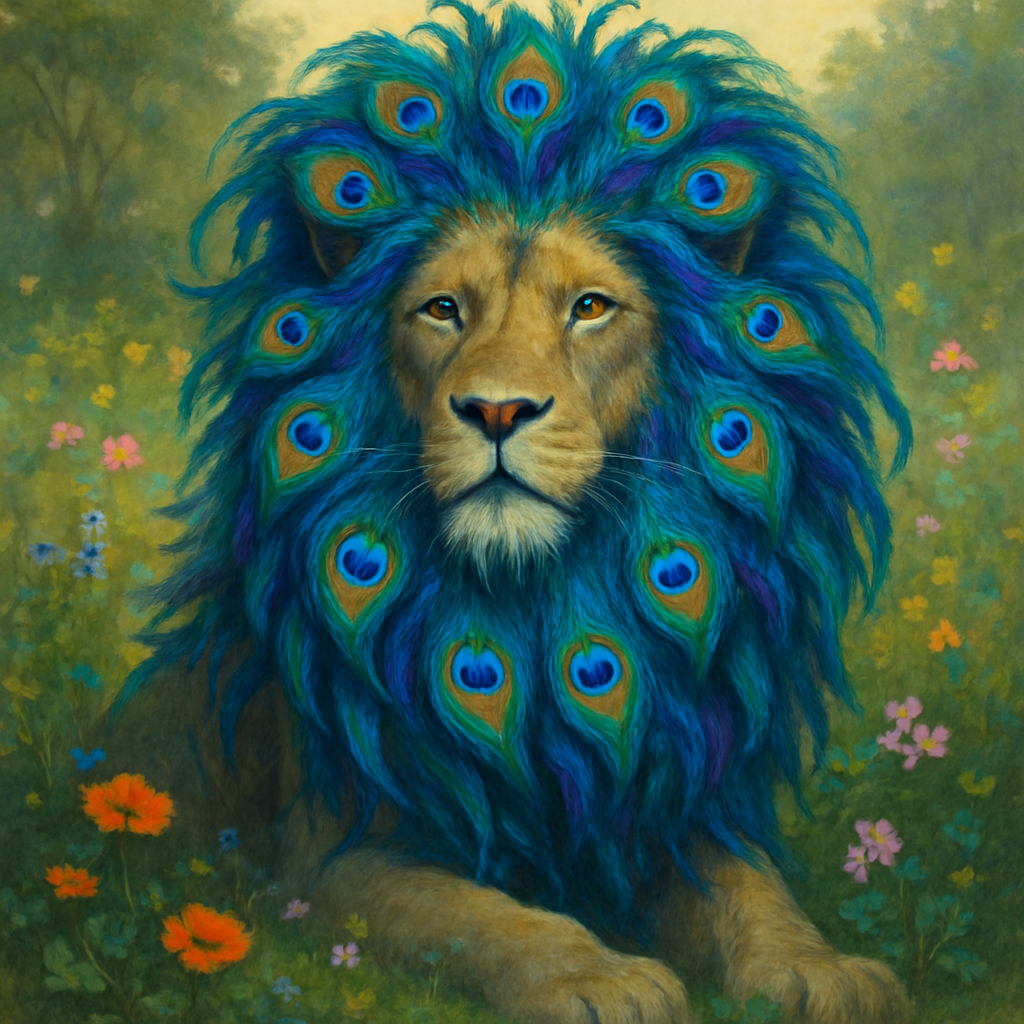

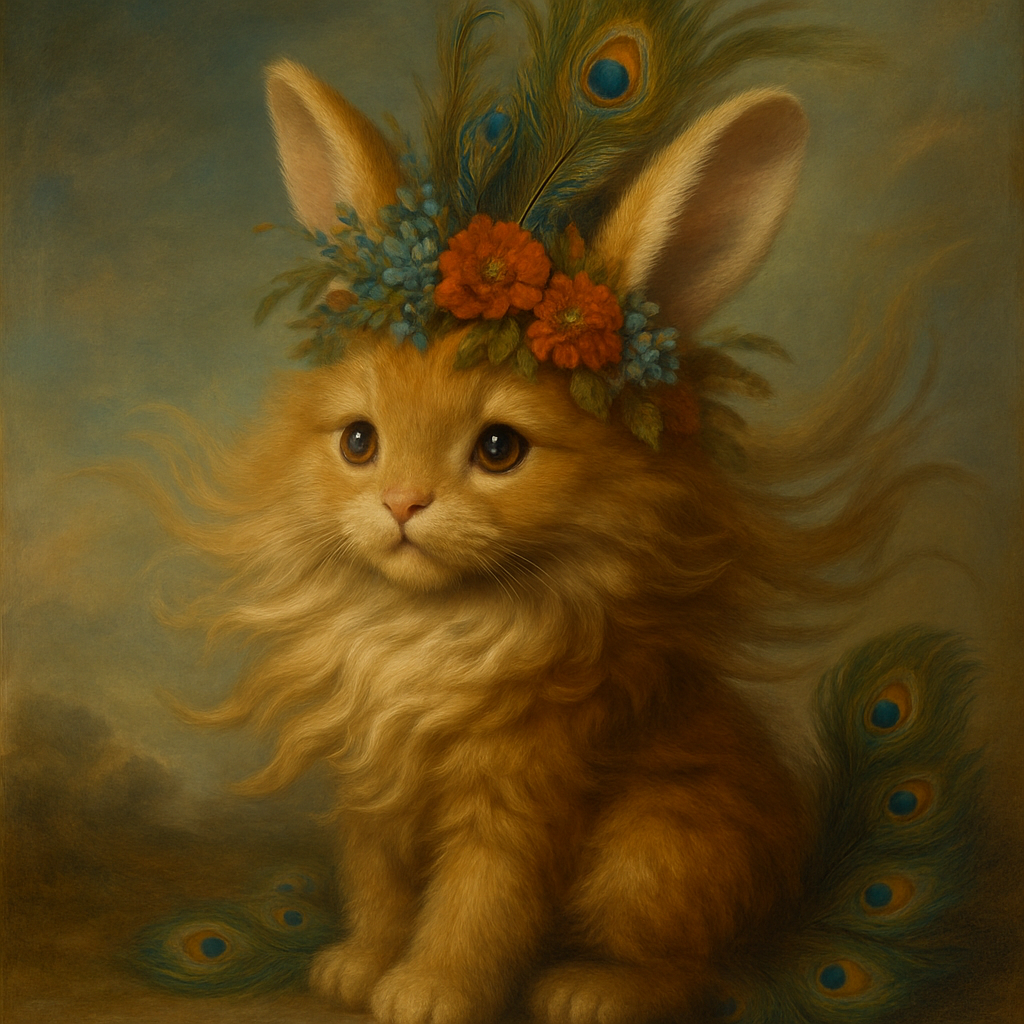

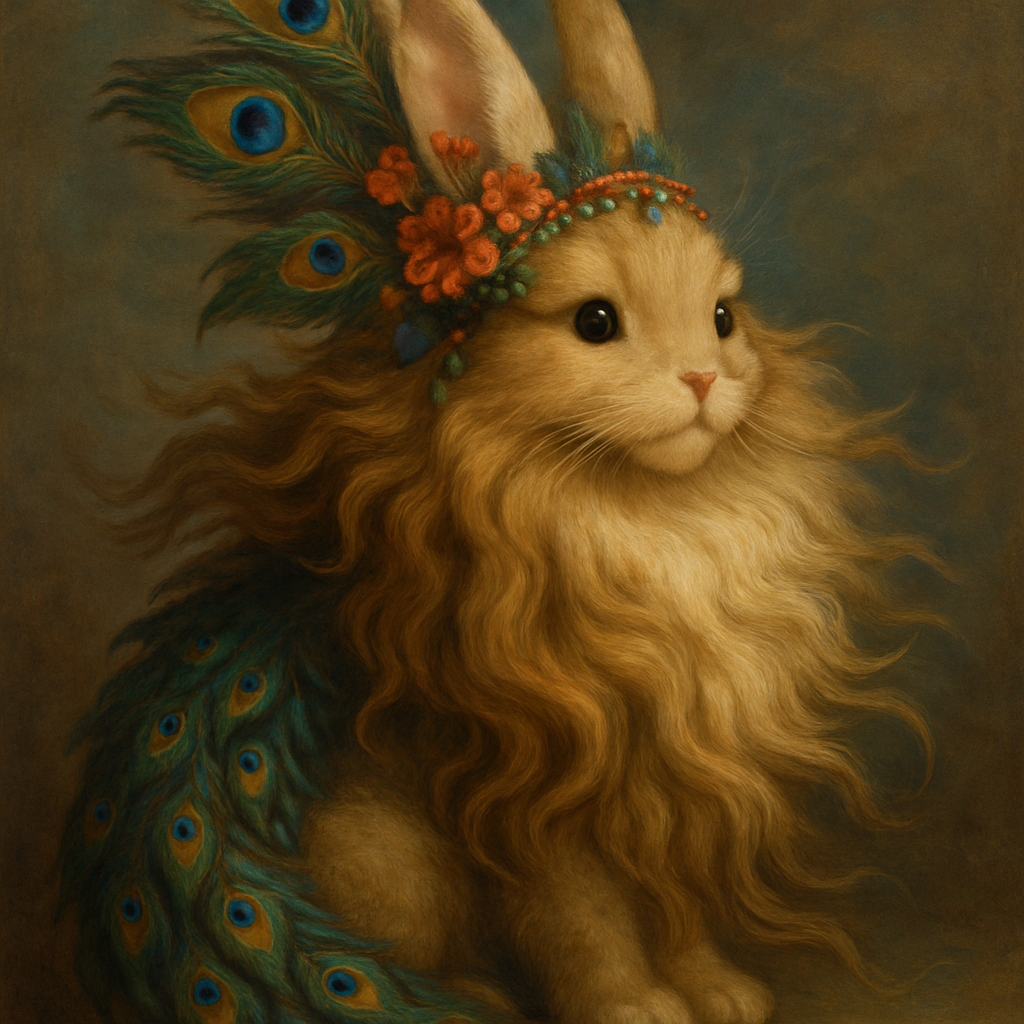

In [29]:
# 예제 12.24 준비한 3개의 프롬프트로 이미지 생성 (수정본)

from IPython.display import display

required_vars = ["described_result", "original_prompt", "dataset", "searched_idx"]
missing_vars = [v for v in required_vars if v not in globals()]

if missing_vars:
    raise RuntimeError(
        f"다음 변수가 아직 정의되지 않았습니다: {missing_vars}\n"
        "예제 12.14 ~ 12.22 셀을 먼저 순서대로 실행하세요."
    )

# 1. GPT-4o가 만든 프롬프트로 이미지 생성
gpt4o_prompt_image = generate_image(
    described_result,
    filename="gpt4o_prompt.png"
)
display(gpt4o_prompt_image)

# 2. 원본 프롬프트로 이미지 생성
original_prompt_image = generate_image(
    original_prompt,
    filename="original_prompt.png"
)
display(original_prompt_image)

# 3. 이미지 임베딩으로 검색한 유사 프롬프트로 이미지 생성
searched_prompt_image = generate_image(
    dataset[searched_idx]["prompt"],
    filename="searched_prompt.png"
)
display(searched_prompt_image)

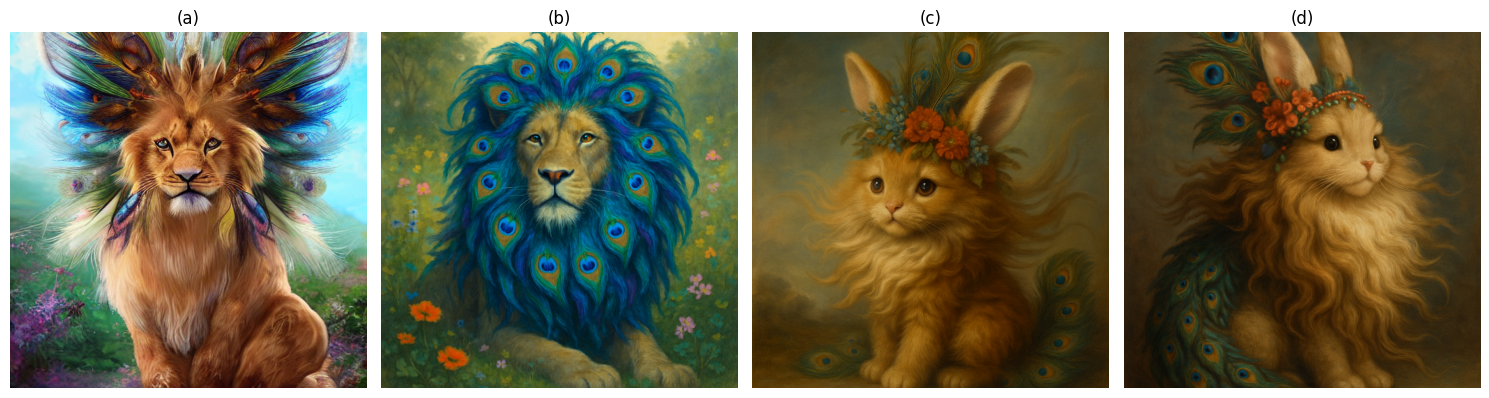

In [30]:
#예제 12.25 이미지 출력

import matplotlib.pyplot as plt

images = [original_image, gpt4o_prompt_image, original_prompt_image, searched_prompt_image]
titles = ['(a)', '(b)', '(c)', '(d)']

fig, axes = plt.subplots(1, len(images), figsize=(15, 5))

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(title)

plt.tight_layout()
plt.show()